In [74]:
#don't change this cell
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)

In [75]:
#don't change this cell
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [76]:
#TODO
FILE_PATH = r".\diabetes.csv"

In [77]:
# #don't change this cell
df = pd.read_csv(FILE_PATH, header=0)

# Rename Outcome to Diagnosis and convert to binary (already 0/1)
df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [78]:
df['Diagnosis'].value_counts()

Diagnosis
0    500
1    268
Name: count, dtype: int64

Text(0.5, 0, 'BMI')

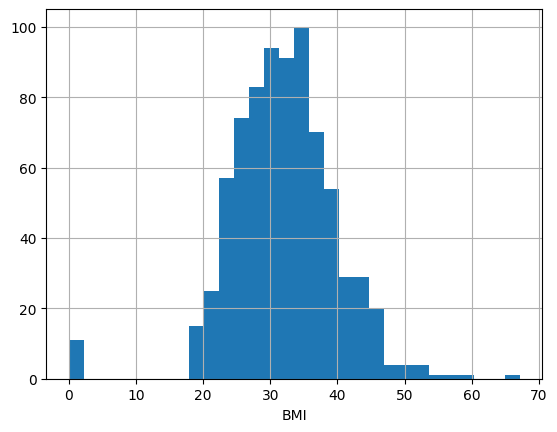

In [79]:
df['BMI'].hist(bins=30)
plt.xlabel('BMI')

Text(0.5, 0, 'Glucose')

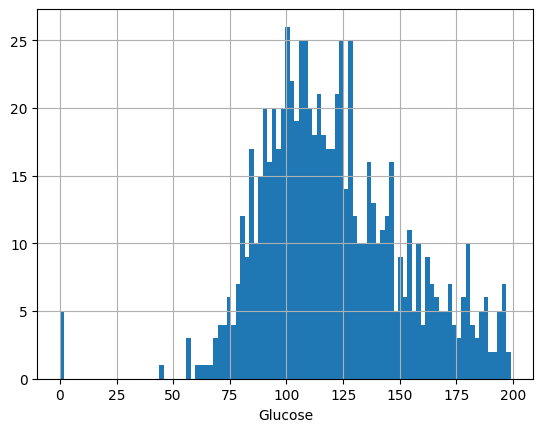

In [80]:
df['Glucose'].hist(bins=100)
plt.xlabel('Glucose')

Text(0.5, 0, 'BloodPressure')

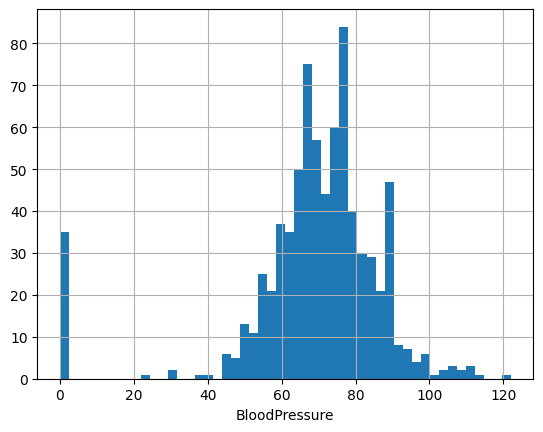

In [81]:
df['BloodPressure'].hist(bins=50)
plt.xlabel('BloodPressure')

Text(0.5, 0, 'Insulin')

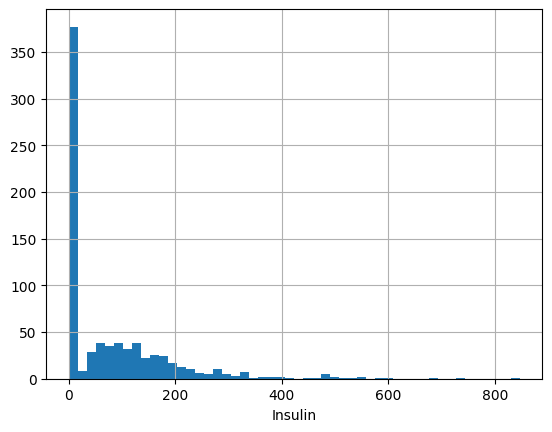

In [82]:
df['Insulin'].hist(bins=50)
plt.xlabel('Insulin')

In [83]:
# df[df['BMI'] == 0.0] = df['BMI'].mean()
# df[df['BloodPressure'] == 0.0] = df['BloodPressure'].median()
# df[df['Glucose'] == 0.0] = df['Glucose'].median()

# df[df['Insulin'] == 0.0] = df['Insulin'].mean()
# df[df['SkinThickness'] == 0.0] = df['SkinThickness'].mean()

import numpy as np
columns_to_fix_med = ['Glucose', 'BloodPressure']
columns_to_fix_mea = ['BMI','SkinThickness','Insulin']

for col in columns_to_fix_mea:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    mean_value = df[col].mean()
    df[col] = df[col].replace(np.nan, mean_value)
    
for col in columns_to_fix_med:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    median_value = df[col].median()
    df[col] = df[col].replace(np.nan, median_value)
    

Text(0.5, 0, 'Insulin')

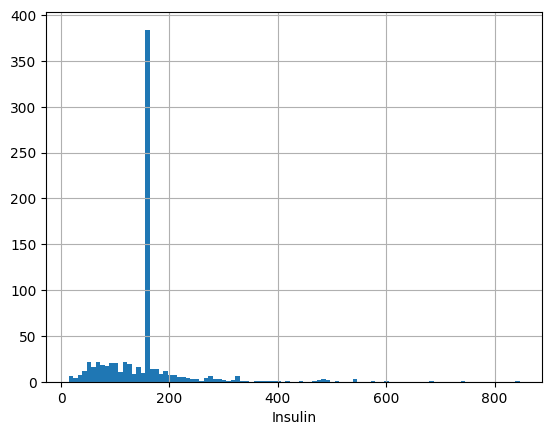

In [84]:
df['Insulin'].hist(bins=100)
plt.xlabel('Insulin')

In [85]:
df.shape

(768, 9)

In [86]:
# don't change this cell
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [87]:

scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_tensor, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [88]:
#TODO
train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=64,
                         shuffle=False )



In [89]:
#TODO
class MLP(nn.Module):
    def __init__(self, input_size, dropout_p=0.5):
        super(MLP, self).__init__()
        # Define the layers (architecture)
        self.model = nn.Sequential(
            nn.Linear(input_size,32), 
            nn.BatchNorm1d(32),
            nn.ReLU(), 
            nn.Dropout(dropout_p),                
            
            nn.Linear(32, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),      
            # nn.Dropout(dropout_p * 0.6375),   
            
            nn.Linear(64, 16), 
            nn.BatchNorm1d(16),
            nn.ReLU(),      
            nn.Dropout(dropout_p * 0.64),   

            nn.Linear(16, 1),          
            nn.Sigmoid()               
        )
    def forward(self, x):
        return self.model(x)

In [90]:
#TODO
input_size = 8
model = MLP(input_size,dropout_p=0.4).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
NUM_EPOCHS = 100

In [91]:
train_accuracy_list= []
test_accuracy_list= []

#TODO
for epoch in range(NUM_EPOCHS):
    model.train()
    total=0
    corrects= 0
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs= inputs.to(device)
        labels= labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() 
        total += labels.size(0)
        predicted = (outputs > 0.5).float()
        corrects += (predicted == labels).sum().item()

    accuracy= corrects / total
    train_accuracy_list.append(accuracy)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {(running_loss / len(train_loader)):.4f}, Acurracy= {accuracy:.4f}")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs= inputs.to(device)
            labels= labels.to(device)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    test_accuracy_list.append(accuracy)
    print(f"Test Accuracy: {accuracy:.4f}", end="\n\n")

Epoch 1/100, Loss: 0.7884, Acurracy= 0.6091
Test Accuracy: 0.6623

Epoch 2/100, Loss: 0.7740, Acurracy= 0.6857
Test Accuracy: 0.7143

Epoch 3/100, Loss: 0.7590, Acurracy= 0.7150
Test Accuracy: 0.7597

Epoch 4/100, Loss: 0.7527, Acurracy= 0.7182
Test Accuracy: 0.7597

Epoch 5/100, Loss: 0.7463, Acurracy= 0.7362
Test Accuracy: 0.7662

Epoch 6/100, Loss: 0.7405, Acurracy= 0.7378
Test Accuracy: 0.7727

Epoch 7/100, Loss: 0.7352, Acurracy= 0.7362
Test Accuracy: 0.7662

Epoch 8/100, Loss: 0.7311, Acurracy= 0.7345
Test Accuracy: 0.7662

Epoch 9/100, Loss: 0.7250, Acurracy= 0.7557
Test Accuracy: 0.7662

Epoch 10/100, Loss: 0.7187, Acurracy= 0.7687
Test Accuracy: 0.7727

Epoch 11/100, Loss: 0.7179, Acurracy= 0.7541
Test Accuracy: 0.7727

Epoch 12/100, Loss: 0.7119, Acurracy= 0.7590
Test Accuracy: 0.7662

Epoch 13/100, Loss: 0.7100, Acurracy= 0.7541
Test Accuracy: 0.7727

Epoch 14/100, Loss: 0.7057, Acurracy= 0.7638
Test Accuracy: 0.7727

Epoch 15/100, Loss: 0.7037, Acurracy= 0.7362
Test Accurac

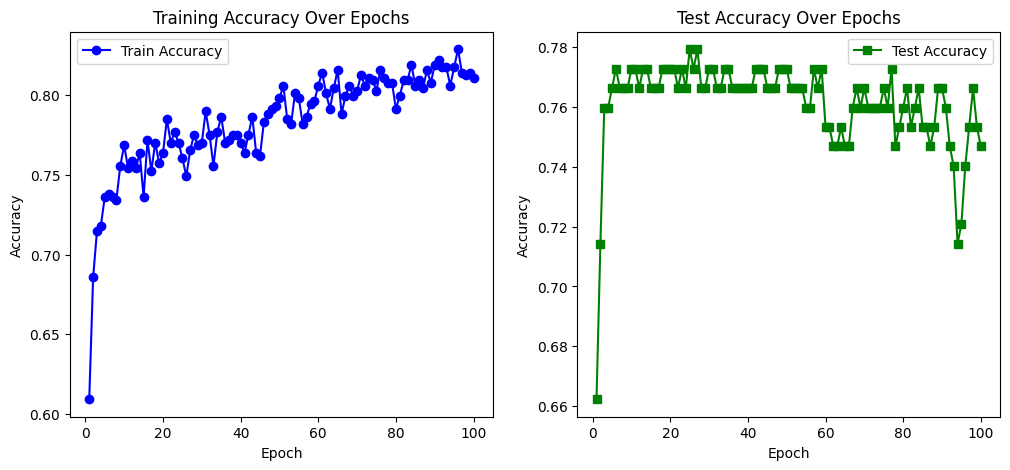

In [92]:
# don't change this cell
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_accuracy_list, marker='o', linestyle='-', color='b', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS+1), test_accuracy_list, marker='s', linestyle='-', color='g', label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Epochs")
plt.legend()

plt.show()